# 08 - Change Point Detection

**Target reader:** someone with limited statistics background who has a long time series and wants to ask: *has something changed during the recording period?*

We work with daily temperature data (`temp.csv`) and with an artificial 'regime shift' that we inject to demonstrate the tests on data with a *known* change point.

## 1. Why do we care about change points?

Environmental and hydrological records are rarely produced by one unchanging process. Typical causes of abrupt change:

* **Climate shifts** - a regime change in ocean-atmosphere circulation (e.g., the 1976-77 Pacific shift).
* **Dam construction** upstream of a gauge - suddenly flows are regulated.
* **Land-use change** - urbanisation, deforestation alter runoff.
* **Instrument changes** - sensor replacement, relocation, new calibration.

### Homogeneity comes first

Almost every statistical method assumes the data are **homogeneous** - drawn from one constant distribution. If there is an unnoticed shift, **trend tests, distribution fits, return periods, and design values are all misleading**. Always check for change points *before* interpreting a trend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statista.time_series import TimeSeries

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 3.5)
plt.rcParams['axes.grid'] = True


## 2. Load data and build a known change point

We load the daily minimum temperature record from Melbourne (`temp.csv`, 1981-1990).
To test the detectors on data with a **known** shift, we also create a `temp_shifted` column that adds +3 degC starting on `1986-01-01`.

In [2]:
DATA_PATH = '../../../examples/data/temp.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['Date']).set_index('Date')
df = df.rename(columns={'Temp': 'temp'})
print('Shape    :', df.shape)
print('Range    :', df.index.min().date(), '->', df.index.max().date())
df.head()


Shape    : (3650, 1)
Range    : 1981-01-01 -> 1990-12-31


,temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [3]:
# Add an artificial +3 degC shift from 1986 onwards
shift_date = pd.Timestamp('1986-01-01')
df['temp_shifted'] = df['temp'] + np.where(df.index >= shift_date, 3.0, 0.0)

ts = TimeSeries(df[['temp', 'temp_shifted']])
ts.head(3), ts.tail(3)


(            temp  temp_shifted
 Date                          
 1981-01-01  20.7          20.7
 1981-01-02  17.9          17.9
 1981-01-03  18.8          18.8,
             temp  temp_shifted
 Date                          
 1990-12-29  13.5          16.5
 1990-12-30  15.7          18.7
 1990-12-31  13.0          16.0)

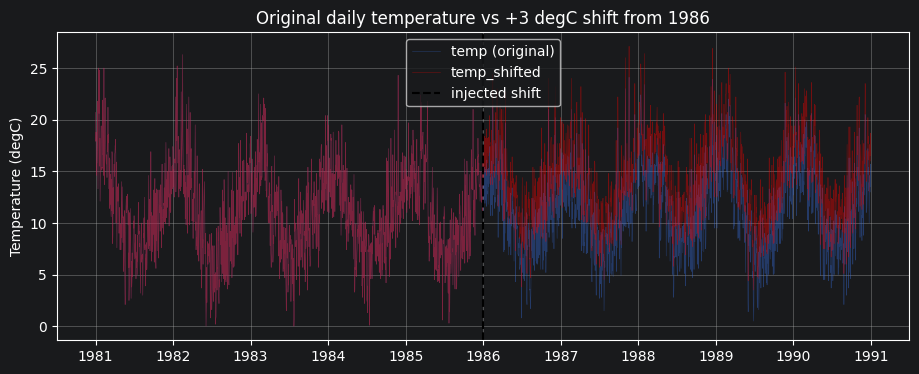

In [4]:
# Visualise the shift
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df['temp'], alpha=0.4, linewidth=0.4, label='temp (original)')
ax.plot(df.index, df['temp_shifted'], alpha=0.4, linewidth=0.4,
        color='red', label='temp_shifted')
ax.axvline(shift_date, color='black', linestyle='--', label='injected shift')
ax.set_ylabel('Temperature (degC)')
ax.set_title('Original daily temperature vs +3 degC shift from 1986')
ax.legend()
plt.show()


## 3. Pettitt test - non-parametric single change point

The **Pettitt test** is the most popular homogeneity test.

### The idea (rank-based)

1. Replace each observation by its **rank** among all observations.
2. For every possible split point *t*, form the statistic `U(t)` which compares the sum of ranks before *t* to what you would expect if the series were homogeneous (random).
3. The **change point** is the *t* that maximises `|U(t)|`.
4. A large maximum `|U|` means the ranks are concentrated on one side of *t* - a shift.

### Null hypothesis

> **H0: the series is homogeneous (no change point).**

* `p_value < alpha` -> reject H0 -> **Inhomogeneous**.
* `p_value >= alpha` -> fail to reject -> **Homogeneous**.

Being *non-parametric* means Pettitt does **not** assume normality - very useful for rainfall or flow data.

In [5]:
pettitt = ts.pettitt_test()
pettitt


,h,change_point_index,statistic,p_value,mean_before,mean_after,conclusion
column,,,,,,,
temp,True,2476,330648.0,2.780374e-06,10.924667,11.712191,Inhomogeneous
temp_shifted,True,1767,1471406.0,2.068734e-116,10.953167,14.297875,Inhomogeneous


In [6]:
# Translate the numeric index into a date
idx = int(pettitt.loc['temp_shifted', 'change_point_index'])
print('Pettitt change point in temp_shifted:', ts.index[idx].date())
print('Injected shift was on              :', shift_date.date())


Pettitt change point in temp_shifted: 1985-11-04
Injected shift was on              : 1986-01-01


## 4. SNHT - Standard Normal Homogeneity Test

**SNHT** (Alexandersson 1986) is a *parametric* test that assumes approximately Normal data.

### The idea

1. Standardise the series (subtract mean, divide by std): z-scores.
2. For every split *t*, compute the average z before *t* and after *t*.
3. The statistic `T(t) = t*mean(z1)^2 + (n-t)*mean(z2)^2` is **large when the two means are very different**.
4. The change point is `argmax T(t)`.

SNHT is **more powerful than Pettitt when the data are close to Normal**, but can be misled by heavy tails or outliers.

In [7]:
snht = ts.snht_test()
snht


,h,change_point_index,statistic,p_value,mean_before,mean_after,conclusion
column,,,,,,,
temp,True,62,163.202548,0.01,17.674603,11.063647,Inhomogeneous
temp_shifted,True,1767,530.238072,0.01,10.953167,14.297875,Inhomogeneous


## 5. Buishand range test

The **Buishand range test** is based on the **adjusted partial sums**:

> `S(k) = sum_{i=1..k} (x_i - mean(x))`

If the series is homogeneous, `S(k)` should wander around zero. If there is a shift, `S(k)` has a pronounced peak (positive shift) or trough (negative shift).

The test statistic is the **range** `R = max(S) - min(S)`, rescaled by the standard deviation and by `sqrt(n)`. Large `R/sqrt(n)` -> reject homogeneity.

In [8]:
buishand = ts.buishand_range_test()
buishand


,h,change_point_index,statistic,p_value,mean_before,mean_after,conclusion
column,,,,,,,
temp,True,2485,4.858002,0.01,10.925342,11.716838,Inhomogeneous
temp_shifted,True,1767,12.834184,0.01,10.953167,14.297875,Inhomogeneous


## 6. CUSUM plot - visual drift check

A **CUSUM** (cumulative sum) plot shows the same partial sums `S(k)` that drive the Buishand test. Reading it is intuitive:

* If the line **drifts upward**, the mean of recent values is above the overall mean (upward shift).
* If the line **drifts downward**, a downward shift.
* If the line wiggles around zero, no shift.

The dashed red line marks the *location* where `|S(k)|` is largest - the candidate change point.

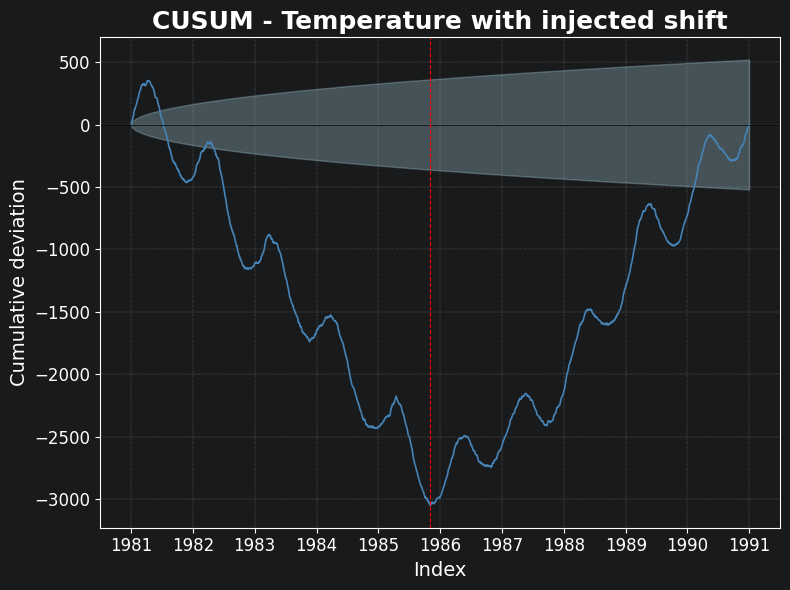

In [9]:
cusum_df, (fig, ax) = ts.cusum(column='temp_shifted',
                               title='CUSUM - Temperature with injected shift')


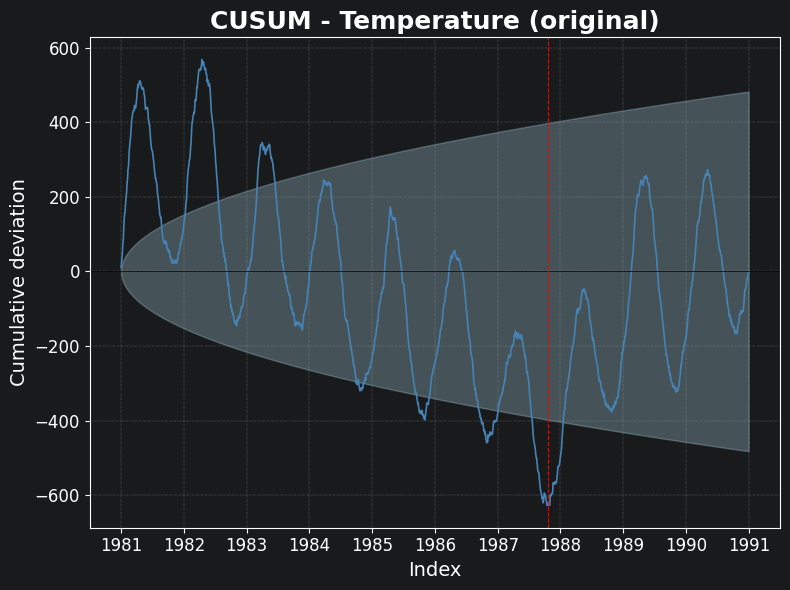

In [10]:
# For comparison: CUSUM of the ORIGINAL (homogeneous) series
cusum_df_orig, _ = ts.cusum(column='temp',
                            title='CUSUM - Temperature (original)')


Notice how the shifted series produces a strong trend in its CUSUM, while the original series wanders around zero.

## 7. Combined diagnosis: `homogeneity_summary`

Each individual test can be fooled - by heavy tails, by outliers, by trends. The `homogeneity_summary` method runs **all three tests** (Pettitt, SNHT, Buishand) and marks a change point as *confirmed* when **at least two tests agree on a location** (within +/-2 indices).

This is the standard workflow in climate-record homogenisation (e.g., pyhomogeneity, RHtests).


In [11]:
summary = ts.homogeneity_summary()
summary


,pettitt_cp,pettitt_p,snht_cp,snht_p,buishand_cp,buishand_p,confirmed
column,,,,,,,
temp,2476,2.780374e-06,62,0.01,2485,0.01,False
temp_shifted,1767,2.068734e-116,1767,0.01,1767,0.01,True


In [12]:
for col in ts.columns:
    row = summary.loc[col]
    verdict = 'CONFIRMED change point' if row['confirmed'] else 'no change point confirmed'
    print(f"{col:15s} -> {verdict}")
    if row['confirmed']:
        idx = int(row['pettitt_cp'])
        print(f"   Pettitt date : {ts.index[idx].date()} (p={row['pettitt_p']:.4f})")
        idx = int(row['snht_cp'])
        print(f"   SNHT    date : {ts.index[idx].date()} (p={row['snht_p']:.4f})")
        idx = int(row['buishand_cp'])
        print(f"   Buishand date: {ts.index[idx].date()} (p={row['buishand_p']:.4f})")


temp            -> no change point confirmed
temp_shifted    -> CONFIRMED change point
   Pettitt date : 1985-11-04 (p=0.0000)
   SNHT    date : 1985-11-04 (p=0.0100)
   Buishand date: 1985-11-04 (p=0.0100)


## 8. Summary

* **Homogeneity testing** comes before trend analysis and distribution fitting. A hidden regime shift corrupts every downstream result.
* **Pettitt** - non-parametric, rank-based, robust to outliers. First choice for non-normal data.
* **SNHT** - parametric, powerful when data are approximately Normal.
* **Buishand range** - based on adjusted partial sums; complements the other two.
* **CUSUM plot** - visual counterpart. Drift upward/downward indicates a shift.
* **`homogeneity_summary`** - runs all three and marks a change point as *confirmed* when >=2 tests agree within +/-2 indices. Use this as your go-to diagnostic.
